# Modelling and Tracking Shared E-Scooters under Correlated Noise in Urban Environments

## Roman Branovets, Skoltech, 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, exp

### Part I. Effects of Ignoring Correlated State and Measurement Noise in Kalman Filtering

We consider a scenario where the motion model is perturbed by CORRELATED random acceleration $a_i \, m/s^2$

$$
x_i = x_{i-1} + V_{i-1}T + \frac{a_{i-1}T^2}{2} \tag{1}
$$

$$
V_i = V_{i-1} + a_{i-1}T
$$

Let's assume that the correlated random acceleration $a_i$ can be described by a first-order Gauss-Markov process

$$
a_i = e^{-\lambda T}a_{i-1} + \zeta_i \tag{2}
$$

Here $\zeta_i$ is uncorrelated random noise with variance $\sigma_\zeta^2 = \sigma_a^2(1 - e^{-2\lambda T})$, $\sigma_a^2$ is the variance of the correlated noise $\sigma_a^2$.

The true trajectory is generated according to Equation 1, utilizing the random acceleration $a_i$ with a variance of $\sigma_a^2 = 0.2^2$ $(m/s^2)^2$ obtained from Equation 2. The trajectory will consist of 200 points, starting with initial conditions $x_1 = 5$ m, $V_1 = 1$ m/s and a time step $T = 1$ s. We will consider the following four scenarios.

**1. Scenario 1. Optimal Kalman filter for uncorrelated state and measurement noise.\
Baseline case: both process and measurement noises are white and independent.**

Generating of the true trajectory and state noise $a_i$

In [2]:
#generating_trajectory
steps=200
lamb = 1000
t=1
sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
x_real=np.zeros(steps)
v_real=np.zeros(steps)
a = np.zeros(steps)
a[0] = np.random.normal(0,0.2)
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
    v_real[i]=v_real[i-1]+a[i]*t

Generating measurements $z_i$ of the coordinate $x_i$ using the following equation:  

$$
z_i = x_i + \eta_i
$$

where $\eta_i$ represents random correlated noise, which can be also modeled by a first-order Gauss-Markov process  

$$
\eta_i = e^{-\lambda T} \eta_{i-1} + ς_i \tag{3}
$$

here, $\zeta_i$ is uncorrelated random noise with variance a given by  

$$
\sigma_{ς}^2 = \sigma_{\eta}^2 (1 - e^{-2\lambda T})
$$

Where $\sigma_{\eta}^2 = 20^2$ is the variance of measurement noise. To generate uncorrelated noise $\eta_i$, set $\lambda = 1000$.

In [3]:
#generating_measurements
z=np.zeros(steps)
lamb = 1000
eta = np.zeros(steps)
eta[0] = np.random.normal(0, 20)
sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lamb*t)))
for i in range(0,steps):
    eta[i] = exp(-lamb * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
    z[i]=x_real[i]+eta[i]

Implementing a Kalman filter algorithm

$$
\begin{aligned}
X_i &= \Phi X_{i-1} + Ga_i \\
z_i &= H_i X_i + \eta_i
\end{aligned}
$$

In [4]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((steps, 2, 1))

In [5]:
#Initial filtered estimate
X[0]=np.matrix([[5],[1]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]

Let's plot meausrement, true trajectory and filtered estimates

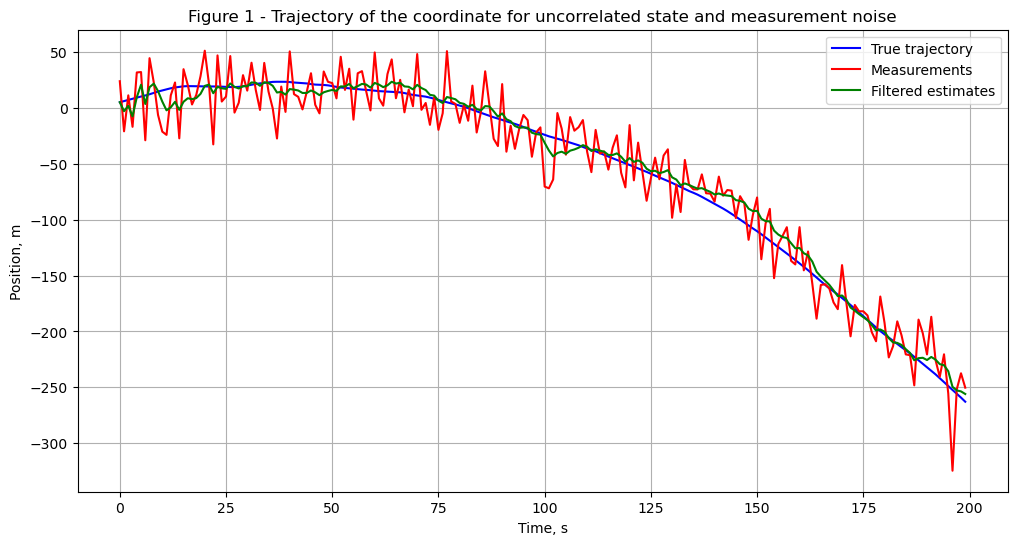

In [6]:
#Plots of real coordinates, measurements and filtered estimates
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.title('Figure 1 - Trajectory of the coordinate for uncorrelated state and measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

Run the filter 𝑀 = 500 times and compare the calculated error (as defined from the filter) with
the true error of the filtered estimate $𝑥_{𝑖,𝑖}$
for the coordinate $𝑥_𝑖$
.

In [7]:
 #calculate error for filtration
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    lamb = 1000
    t=1
    sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    a = np.zeros(steps)
    a[0] = np.random.normal(0,0.2)
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
        v_real[i]=v_real[i-1]+a[i]*t
    #generating_measurements
    z=np.zeros(steps)
    lamb = 1000
    eta = np.zeros(steps)
    eta[0] = np.random.normal(0, 20)
    sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lamb*t)))
    for i in range(0,steps):
        eta[i] = exp(-lamb * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
        z[i]=x_real[i]+eta[i]
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[5],[1]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

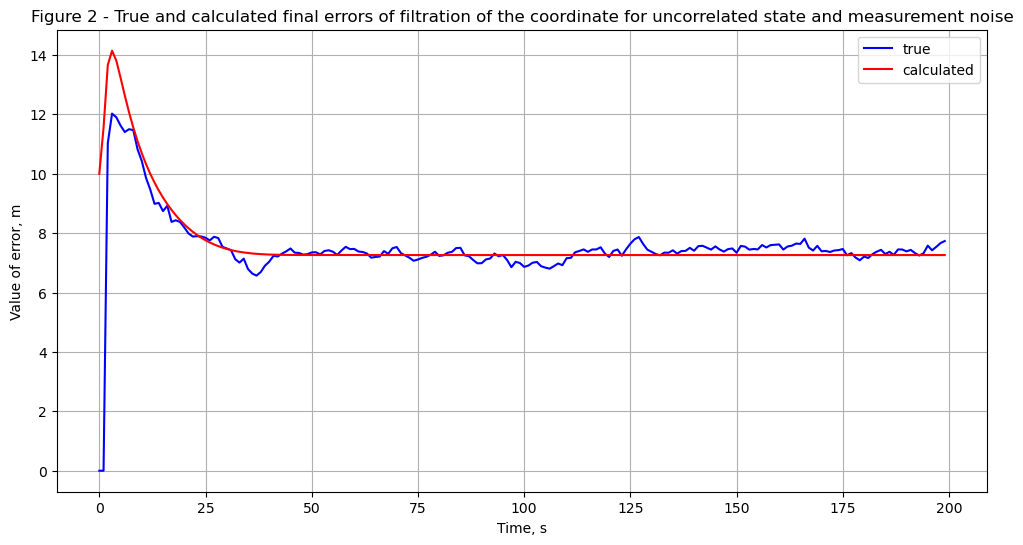

In [8]:
#Plot of the true and calculated errors of filtration
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='calculated')
plt.title('Figure 2 - True and calculated final errors of filtration of the coordinate for uncorrelated state and measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

The calculated error aligns with the true error.
Given that this filter is constructed under accurate assumptions about uncorrelated state and
measurement noise, it provides optimal estimates, allowing us to confidently rely on the
calculated error for our decision-making.

**2. Scenario 2. Effects of ignoring correlated state noise in Kalman filtering. Non-optimal filter:
assumes uncorrelated state noise, but true acceleration is correlated.**

Generating the true trajectory and measurements once more, using $𝜆 = 0.1$ to produce correlated
random acceleration $𝒂_𝒊$ according to Equation (2) and $𝜆 = 1000$ to create uncorrelated random
measurements $\eta_𝒊$
.


In [9]:
#generating_trajectory
steps=200
lamb = 0.1
t=1
sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
x_real=np.zeros(steps)
v_real=np.zeros(steps)
a = np.zeros(steps)
a[0] = np.random.normal(0,0.2)
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
    v_real[i]=v_real[i-1]+a[i]*t
#generating_measurements
z=np.zeros(steps)
lamb = 1000
eta = np.zeros(steps)
eta[0] = np.random.normal(0, 20)
sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lamb*t)))
for i in range(0,steps):
    eta[i] = exp(-lamb * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
    z[i]=x_real[i]+eta[i]

Implementing a Kalman filter algorithm

In [10]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((steps, 2, 1))

In [11]:
#Initial filtered estimate
X[0]=np.matrix([[5],[1]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]

Let's plot meausrement, true trajectory and filtered estimates

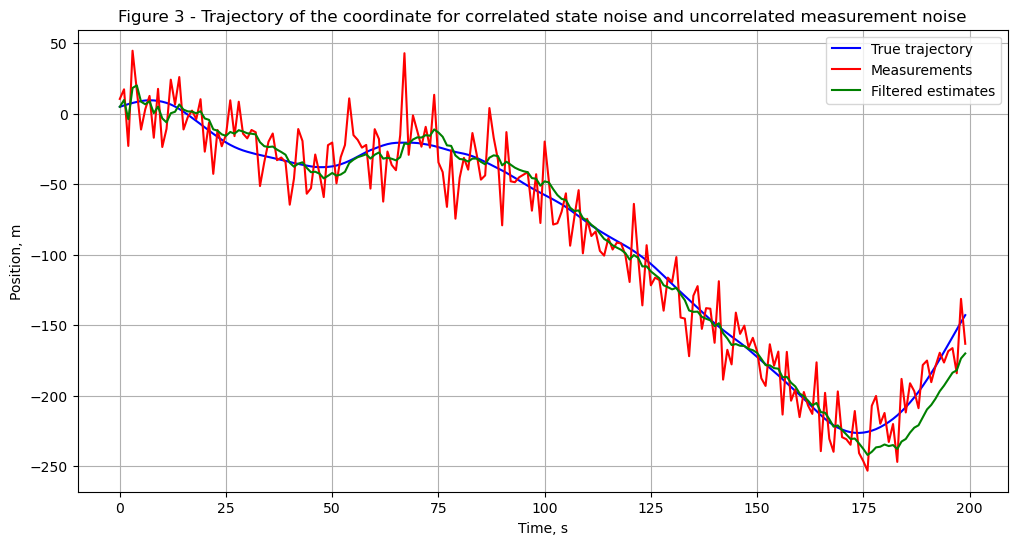

In [12]:
#Plots of real coordinates, measurements and filtered estimates
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.title('Figure 3 - Trajectory of the coordinate for correlated state noise and uncorrelated measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

Run the filter 𝑀 = 500 times and compare the calculated error (as defined from the filter) with
the true error of the filtered estimate $𝑥_{𝑖,𝑖}$
for the coordinate $𝑥_𝑖$
.

In [13]:
 #calculate error for filtration
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    lamb = 0.1
    t=1
    sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    a = np.zeros(steps)
    a[0] = np.random.normal(0,0.2)
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
        v_real[i]=v_real[i-1]+a[i]*t
    #generating_measurements
    z=np.zeros(steps)
    lamb = 1000
    eta = np.zeros(steps)
    eta[0] = np.random.normal(0, 20)
    sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lamb*t)))
    for i in range(0,steps):
        eta[i] = exp(-lamb * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
        z[i]=x_real[i]+eta[i]
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[5],[1]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

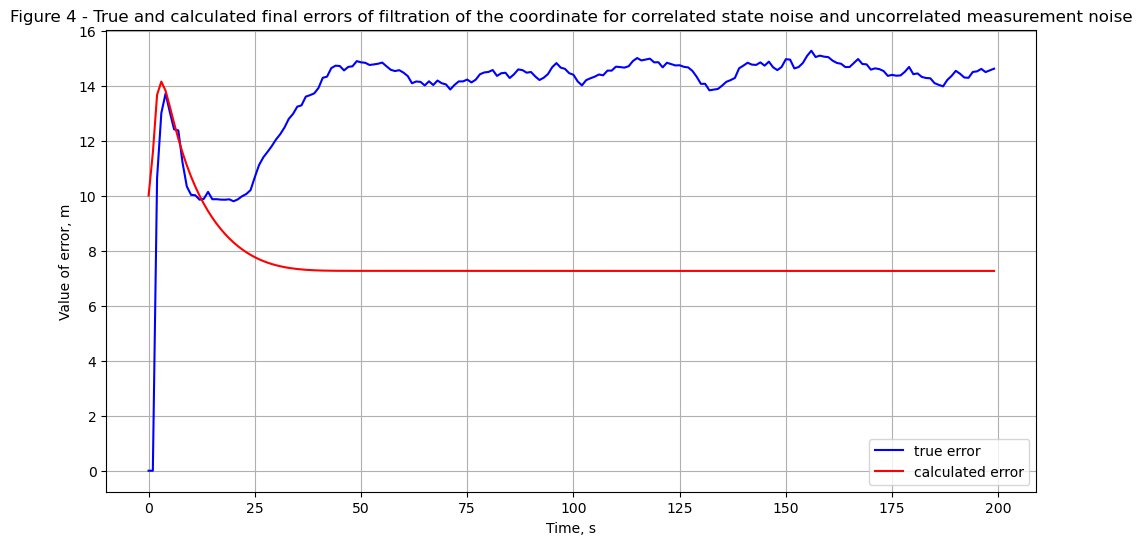

In [14]:
#Plot of the true and calculated errors of filtration
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true error')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='calculated error')
plt.title('Figure 4 - True and calculated final errors of filtration of the coordinate for correlated state noise and uncorrelated measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

The calculated error doesn't align with the true error.
Since the correlated state noise is neglected in the Kalman filter algorithm, the true error significantly greater than the calculated error, indicating that the filter is non-optimal and that
we cannot rely on the calculated error for our decisions.

Let's compare the resulting true error with the standard deviation of the measurement noise

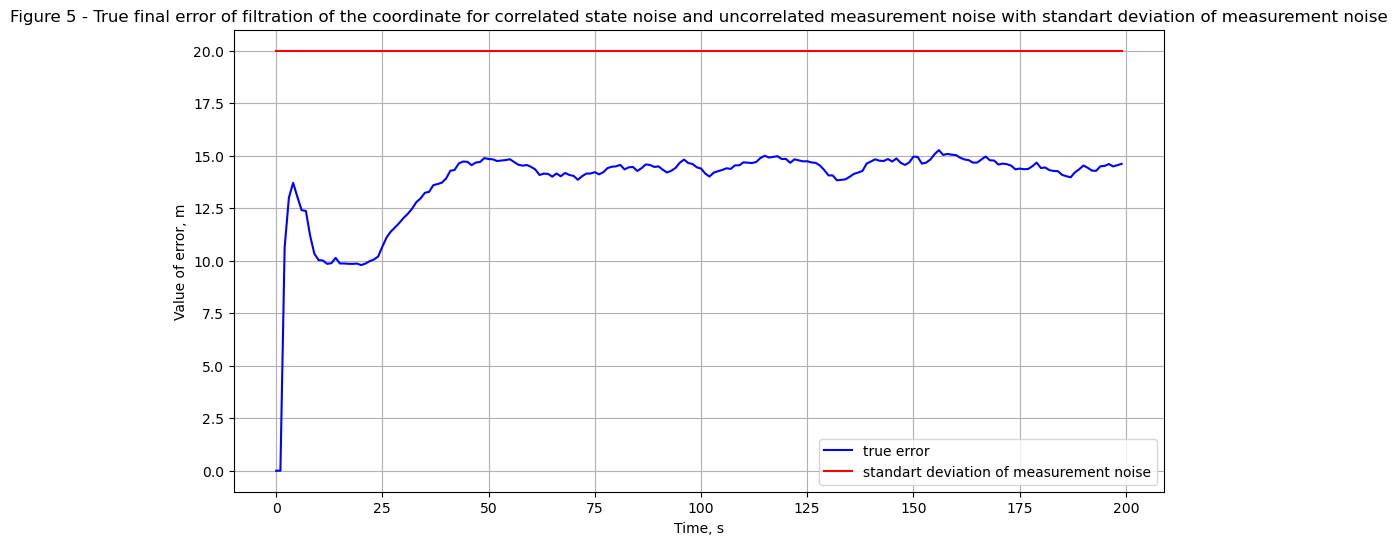

In [15]:
#Plot of the true error of filtration and standart deviation of the measurement noise
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true error')
plt.plot(np.repeat(20, 200), color="red",  label='standart deviation of measurement noise')
plt.title('Figure 5 - True final error of filtration of the coordinate for correlated state noise and uncorrelated measurement noise with standart deviation of measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

The filter performs some smoothing — its estimates are closer to the true trajectory than the measurements. However, this smoothing is non-optimal. We see that when the optimal filter was running, the true final error turned out to be 2 times less than in the non-optimal filter.

**3. Scenario 3. Impact of correlated measurement noise on filter consistency. Non-optimal filter:
assumes uncorrelated measurement noise, but true observations are correlated.**


Generating the true trajectory and measurements using
$𝜆 = 1000$ to produce uncorrelated random acceleration $𝒂_𝒊$
, and $𝜆 = 0.1$ to create correlated
random measurements $\eta_𝒊$
.

In [16]:
#generating_trajectory
steps=200
lamb = 1000
t=1
sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
x_real=np.zeros(steps)
v_real=np.zeros(steps)
a = np.zeros(steps)
a[0] = np.random.normal(0,0.2)
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
    v_real[i]=v_real[i-1]+a[i]*t
#generating_measurements
z=np.zeros(steps)
lamb = 0.1
eta = np.zeros(steps)
eta[0] = np.random.normal(0, 20)
sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lamb*t)))
for i in range(0,steps):
    eta[i] = exp(-lamb * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
    z[i]=x_real[i]+eta[i]

Implementing a Kalman filter algorithm

In [17]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((steps, 2, 1))

In [18]:
#Initial filtered estimate
X[0]=np.matrix([[5],[1]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]

Let's plot meausrement, true trajectory and filtered estimates

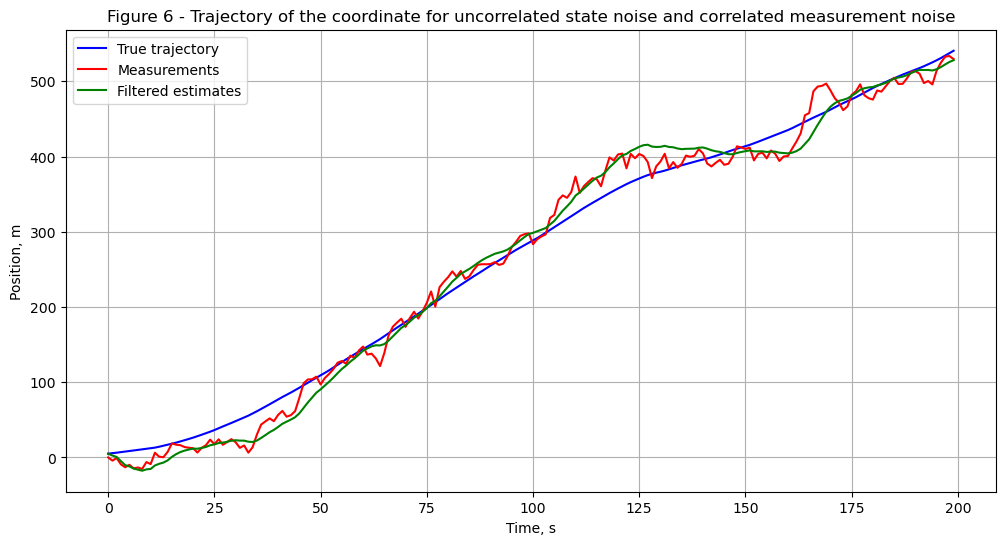

In [19]:
#Plots of real coordinates, measurements and filtered estimates
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.title('Figure 6 - Trajectory of the coordinate for uncorrelated state noise and correlated measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

Run the filter 𝑀 = 500 times and compare the calculated error (as defined from the filter) with
the true error of the filtered estimate $𝑥_{𝑖,𝑖}$
for the coordinate $𝑥_𝑖$
.

In [20]:
 #calculate error for filtration
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    lamb = 1000
    t=1
    sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    a = np.zeros(steps)
    a[0] = np.random.normal(0,0.2)
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
        v_real[i]=v_real[i-1]+a[i]*t
    #generating_measurements
    z=np.zeros(steps)
    lamb = 0.1
    eta = np.zeros(steps)
    eta[0] = np.random.normal(0, 20)
    sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lamb*t)))
    for i in range(0,steps):
        eta[i] = exp(-lamb * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
        z[i]=x_real[i]+eta[i]
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[5],[1]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

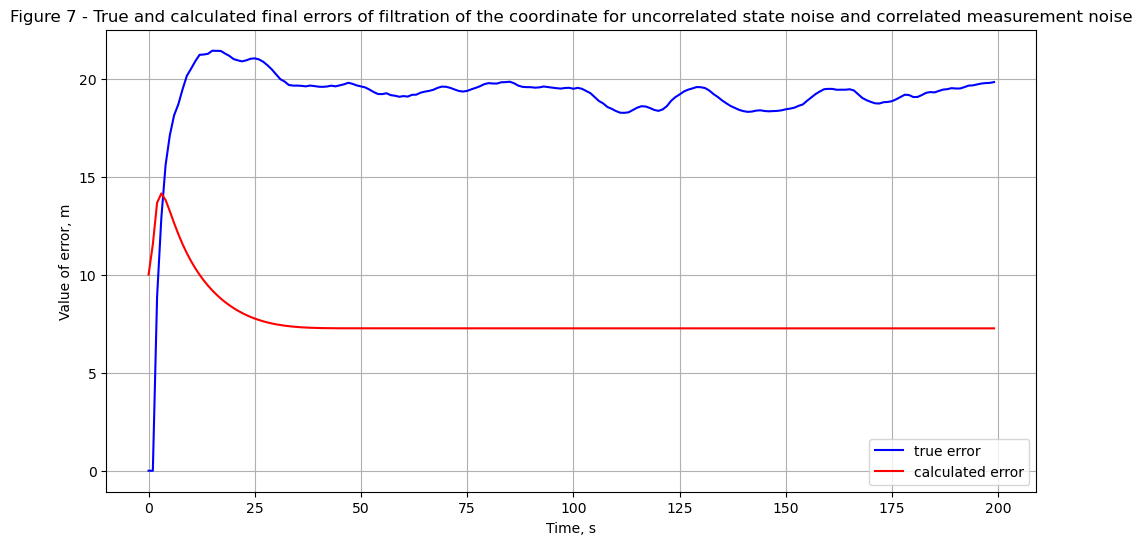

In [21]:
#Plot of the true and calculated errors of filtration
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true error')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='calculated error')
plt.title('Figure 7 - True and calculated final errors of filtration of the coordinate for uncorrelated state noise and correlated measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

The calculated error doesn't align with the true error. Since the correlated measurement noise is neglected in the Kalman filter algorithm, the true error significantly greater than the calculated error, indicating that the filter is non-optimal and that we cannot rely on the calculated error for our decisions.

Let's compare the resulting true error with the standard deviation of the measurement noise

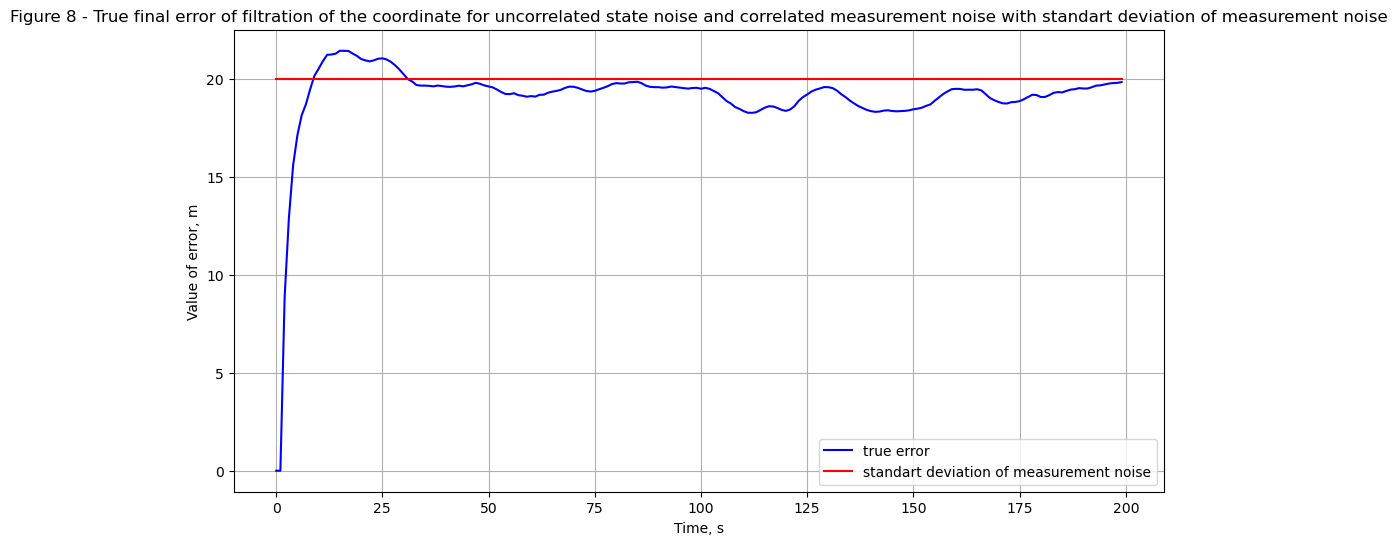

In [22]:
#Plot of the true error of filtration and standart deviation of the measurement noise
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true error')
plt.plot(np.repeat(20, 200), color="red",  label='standart deviation of measurement noise')
plt.title('Figure 8 - True final error of filtration of the coordinate for uncorrelated state noise and correlated measurement noise with standart deviation of measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

We see that the true final error is almost equal to the standard deviation of the measurement noise. It can be concluded that the filter almost does not filter out the measurements. In this case, when the filter ignores correlated measurement noise and as a result, greater decrease in accuracy under these noise statistics

**4. Scenario 4. Combined effects of ignoring correlated state and measurement noise. Nonoptimal Kalman filter: assumed uncorrelated state and measurement noise vs. actual
correlation of both noises.**

Generating the true trajectory and measurements using
$𝜆 = 0.1$ to produce correlated random acceleration $𝒂_𝒊$
, and $𝜆 = 0.1$ to create correlated
random measurements $\eta_𝒊$
.

In [23]:
#generating_trajectory
steps=200
lamb = 0.1
t=1
sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
x_real=np.zeros(steps)
v_real=np.zeros(steps)
a = np.zeros(steps)
a[0] = np.random.normal(0,0.2)
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
    v_real[i]=v_real[i-1]+a[i]*t
#generating_measurements
z=np.zeros(steps)
lamb = 0.1
eta = np.zeros(steps)
eta[0] = np.random.normal(0, 20)
sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lamb*t)))
for i in range(0,steps):
    eta[i] = exp(-lamb * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
    z[i]=x_real[i]+eta[i]

Implementing a Kalman filter algorithm

In [24]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((steps, 2, 1))

In [25]:
#Initial filtered estimate
X[0]=np.matrix([[5],[1]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]

Let's plot meausrement, true trajectory and filtered estimates

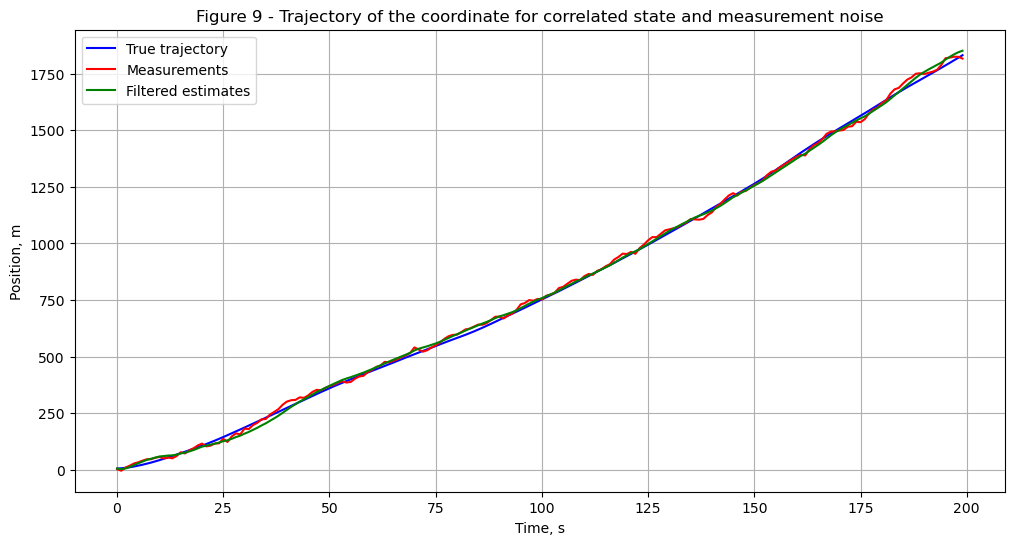

In [26]:
#Plots of real coordinates, measurements and filtered estimates
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.title('Figure 9 - Trajectory of the coordinate for correlated state and measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

Run the filter 𝑀 = 500 times and compare the calculated error (as defined from the filter) with
the true error of the filtered estimate $𝑥_{𝑖,𝑖}$
for the coordinate $𝑥_𝑖$
.

In [27]:
 #calculate error for filtration
M=500
error=np.zeros((M,steps))
fin_err=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    lamb = 0.1
    t=1
    sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    a = np.zeros(steps)
    a[0] = np.random.normal(0,0.2)
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
        v_real[i]=v_real[i-1]+a[i]*t
    #generating_measurements
    z=np.zeros(steps)
    lamb = 0.1
    eta = np.zeros(steps)
    eta[0] = np.random.normal(0, 20)
    sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lamb*t)))
    for i in range(0,steps):
        eta[i] = exp(-lamb * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
        z[i]=x_real[i]+eta[i]
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[5],[1]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i]=fin_err[i]+((1/(M-1))*error[j,i])
    fin_err[i]=sqrt(fin_err[i])

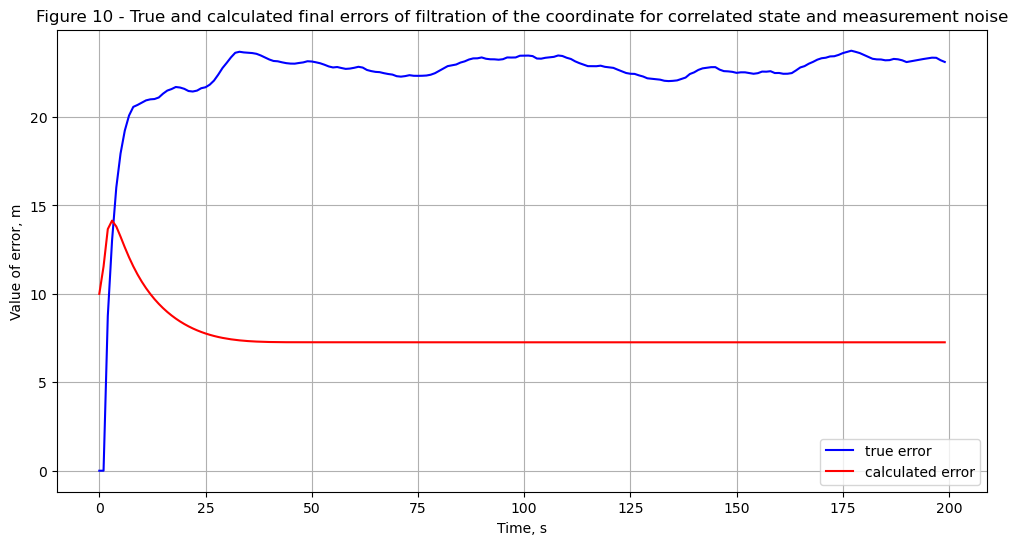

In [28]:
#Plot of the true and calculated errors of filtration
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true error')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='calculated error')
plt.title('Figure 10 - True and calculated final errors of filtration of the coordinate for correlated state and measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

The calculated error doesn't align with the true error. Since the correlated state and measurement noise are neglected in the Kalman filter algorithm, the true error significantly greater than the calculated error, indicating that the filter is non-optimal and that we cannot rely on the calculated error for our decisions.

Let's compare the resulting true error with the standard deviation of the measurement noise

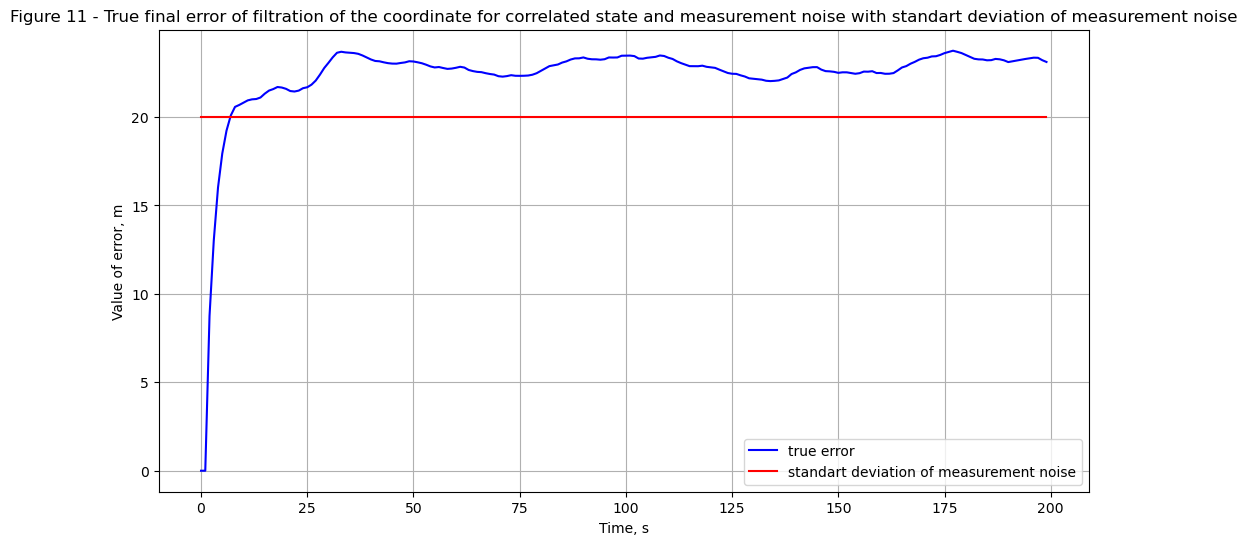

In [29]:
#Plot of the true error of filtration and standart deviation of the measurement noise
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true error')
plt.plot(np.repeat(20, 200), color="red",  label='standart deviation of measurement noise')
plt.title('Figure 11 - True final error of filtration of the coordinate for correlated state and measurement noise with standart deviation of measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

We see that the filter outputs an error greater than the standard deviation of the measurement noise. In this regard, we can conclude that if the Kalman filter does not take into account the correlation of both noises, then it produces a filtered result with an accuracy lower than the raw measurements. Its use in this case is useless, as it makes even more inaccurate data out of inaccurate data.

### Part II. Optimal Kalman Filtering with Correlated State Noise

1. Generating the true trajectory using Equation (1) and measurements using $𝜆 = 0.1$ to produce
correlated random acceleration $𝒂_𝒊$ according to Equation (2) and $𝜆 = 1000$ to create
uncorrelated random measurements $\eta_𝒊$ according to Equation (3), maintaining the same noise
statistics and initial conditions as in Part I.

In [30]:
#generating_trajectory
steps=200
lamb = 0.1
t=1
sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
x_real=np.zeros(steps)
v_real=np.zeros(steps)
a = np.zeros(steps)
a[0] = np.random.normal(0,0.2)
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
    v_real[i]=v_real[i-1]+a[i]*t

In [31]:
#generating_measurements
z=np.zeros(steps)
lambdaz = 1000
eta = np.zeros(steps)
eta[0] = np.random.normal(0, 20)
sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lambdaz*t)))
for i in range(0,steps):
    eta[i] = exp(-lambdaz * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
    z[i]=x_real[i]+eta[i]

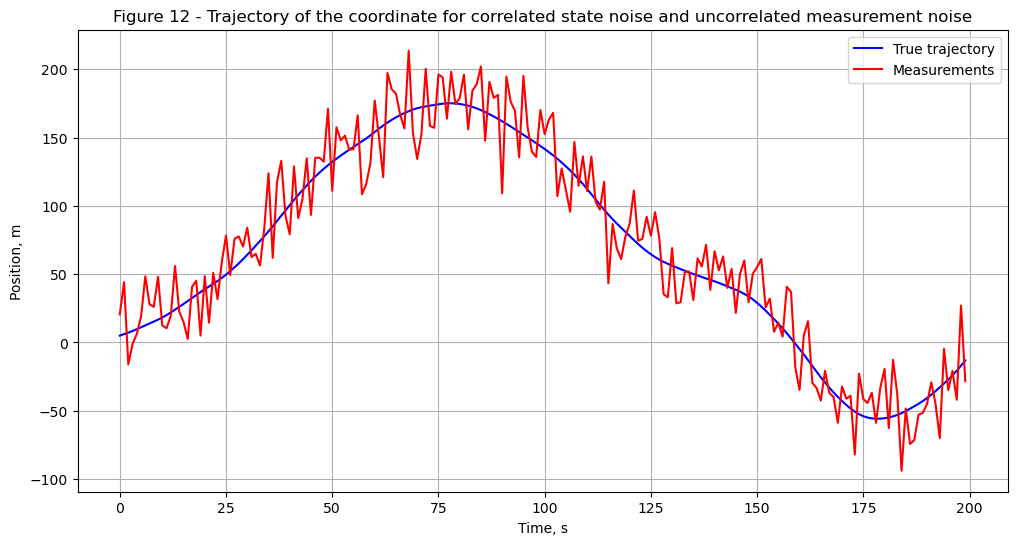

In [32]:
#Plots of real coordinates and measurements
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.title('Figure 12 - Trajectory of the coordinate for correlated state noise and uncorrelated measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

**2. Preparations for developing an optimal Kalman Filter algorithm that accounts for correlated
state noise (acceleration).**

* In case of **correlated** random acceleration, the motion of the object is described by the following equations
$$x_{i} = x_{i-1}+V_{i-1}T+\frac{a_{i-1}T^{2}}{2}\tag{4}$$ 
$$V_{i} = V_{i-1}+a_{i-1}T$$
$$a_{i} = e^{-\lambda T}a_{i-1}+\zeta_{i}$$

* To construct the Kalman filter, we first need to represent the system in **state space**. The state vector is defined as
$$X_{i}=\begin{vmatrix}x_{i}\\ V_{i}\\ a_{i}\end{vmatrix}$$
This representation indicates that the state vector $X_{i}$ is extended to include **correlated random acceleration $a_{i}$**. Consequently, the Kalman filter algorithm will provide estimates not only for the coordinate $x_{i}$ and velocity $V_{i}$, but also for the acceleration $a_{i}$. When random acceleration is **correlated**, it is characterized by specific dynamics that must be estimated, in contrast to white noise.

 **State equation** is given by
$$X_{i}=\Phi X_{i-1}+G\zeta_{i}\tag{5}$$
Here, $\Phi$ represents the transition matrix, which we will need to identify based on the provided motion model (Equation 4). The term $G\zeta_{i}$ denotes the state noise, where $\zeta_{i}$ is **uncorrelated** noise with a variance of $\sigma_{\zeta}^{2}=\sigma_{a}^{2}(1-e^{-2\lambda T})$.

**Measurement equation** is given by

$$z_{i}=HX_{i}+\eta_{i}\tag{6}$$

Let's define the parameters of this system

In [33]:
#transition matrix
fi=np.matrix([[1, t, (t**2)/2], [0, 1, t], [0, 0, exp(-lamb*t)]])
#input matrix
g=np.matrix([[0], [0], [1]],)
#observation matrix
h=np.matrix([1, 0, 0])
#state vector
X = np.zeros((len(x_real), 3, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]], [a[i]]])


The covariance matrix $Q$ of the state noise $G \zeta_i$ is defined as follows:  

$$Q = E[ (G \zeta_i)(G \zeta_i)^T ] = $$  
$$= GE[\zeta_i^2]G^T = $$  
$$= G\sigma_\zeta^2G^T = GG^T\sigma_\zeta^2 = GG^T\sigma_a^2(1 - e^{-2\lambda T})$$

**Initial conditions for the Kalman filter algorithm**  
Initial filtered estimate  

$$X_0 = 
\begin{vmatrix} 
2 \\ 
0 \\ 
0 
\end{vmatrix}$$

Initial filtration error covariance matrix  

$$P_{0,0} = 
\begin{vmatrix} 
10000 & 0 & 0 \\ 
0 & 10000 & 0 \\ 
0 & 0 & 10000 
\end{vmatrix}$$

Let's write and configure a Kalman filter

In [34]:
#Initial filtered estimate
X[0]=np.matrix([[2],[0],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 3, 3))
P[0]=np.matrix([[10000, 0, 0], [0, 10000, 0], [0, 0, 10000]])
#Covariance matrix
Q=(g @ g.T) * (0.2**2) * (1 - exp(-2*lamb*t))
R = np.array(20**2)
K = np.zeros((steps, 3, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(3)-K[i]@h)@P[i]

Let's plot meausrement, real trajectory and filtered estimates

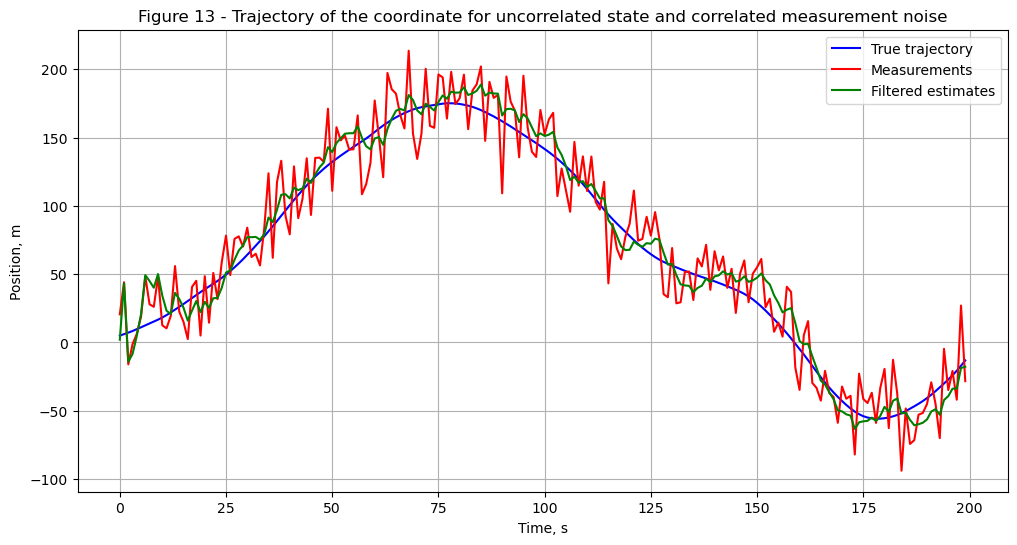

In [35]:
#Plots of real coordinates, measurements and filtered estimates
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.title('Figure 13 - Trajectory of the coordinate for uncorrelated state and correlated measurement noise')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

**3. Obtain estimates of state vector $X_i = 
\begin{vmatrix} 
x_i \\ 
V_i \\ 
a_i 
\end{vmatrix}$ using the Kalman filter over $M = 500 \, \text{runs}$.**

In [36]:
#calculate error for filtration
M=500
error=np.zeros((M,steps))
error_pred = np.zeros((M, steps))
error_v = np.zeros((M,steps))
error_pred_v = np.zeros((M, steps))
error_a = np.zeros((M,steps))
error_pred_a = np.zeros((M, steps))
fin_err = np.zeros(steps)
fin_err_pred = np.zeros(steps)
fin_err_v = np.zeros(steps)
fin_err_pred_v = np.zeros(steps)
fin_err_a = np.zeros(steps)
fin_err_pred_a = np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    lamb = 0.1
    t=1
    sigma_zeta = sqrt(0.2**2 * (1 - exp(-2*lamb*t)))
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    a = np.zeros(steps)
    a[0] = np.random.normal(0,0.2)
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a[i] = exp(-lamb * t) * a[i-1] + np.random.normal(0, sigma_zeta)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a[i]*(t**2))/2)
        v_real[i]=v_real[i-1]+a[i]*t
    #generating_measurements
    z=np.zeros(steps)
    lambdaz = 1000
    eta = np.zeros(steps)
    eta[0] = np.random.normal(0, 20)
    sigma_sigmaf = sqrt(20**2 * (1 - exp(-2*lambdaz*t)))
    for i in range(0,steps):
        eta[i] = exp(-lambdaz * t) * eta[i-1] + np.random.normal(0, sigma_sigmaf)
        z[i]=x_real[i]+eta[i]
    #transition matrix
    fi=np.matrix([[1, t, (t**2)/2], [0, 1, t], [0, 0, exp(-lamb*t)]])
    #input matrix
    g=np.matrix([[0], [0], [1]],)
    #observation matrix
    h=np.matrix([1, 0, 0])
    #state vector
    X = np.zeros((len(x_real), 3, 1))
    X_pred = np.zeros((len(x_real), 3, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]], [a[i]]])
        X_pred[i] = np.array([[x_real[i]], [v_real[i]], [a[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 3, 3))
    P[0]=np.matrix([[10000, 0, 0], [0, 10000, 0], [0, 0, 10000]])
    P_viz=np.zeros((steps, 3, 3))
    P_viz[0]=np.matrix([[10000, 0, 0], [0, 10000, 0], [0, 0, 10000]])
    #Covariance matrix
    Q=(g @ g.T) * (0.2**2) * (1 - exp(-2*lamb*t))
    R = np.array(20**2)
    K = np.zeros((steps, 3, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        X_pred[i] = fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_viz[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(3)-K[i]@h)@P[i]
    for k in range(2,steps):
        error[o,k]=(x_real[k]-X[k,0,0])**2
        error_pred[o,k] = (x_real[k]-X_pred[k,0,0])**2
        error_v[o,k]=(v_real[k]-X[k,1,0])**2
        error_pred_v[o,k] = (v_real[k]-X_pred[k,1,0])**2
        error_a[o,k]=(a[k]-X[k,2,0])**2
        error_pred_a[o,k] = (a[k]-X_pred[k,2,0])**2
for i in range(steps):
    for j in range(M):
        fin_err[i] = fin_err[i]+((1/(M-1))*error[j,i])
        fin_err_pred[i] = fin_err_pred[i] + ((1/(M-1))*error_pred[j,i])
        fin_err_v[i] = fin_err_v[i]+((1/(M-1))*error_v[j,i])
        fin_err_pred_v[i] = fin_err_pred_v[i] + ((1/(M-1))*error_pred_v[j,i])
        fin_err_a[i] = fin_err_a[i]+((1/(M-1))*error_a[j,i])
        fin_err_pred_a[i] = fin_err_pred_a[i] + ((1/(M-1))*error_pred_a[j,i])
    fin_err[i]=sqrt(fin_err[i])
    fin_err_pred[i] = sqrt(fin_err_pred[i])
    fin_err_v[i]=sqrt(fin_err_v[i])
    fin_err_pred_v[i] = sqrt(fin_err_pred_v[i])
    fin_err_a[i]=sqrt(fin_err_a[i])
    fin_err_pred_a[i] = sqrt(fin_err_pred_a[i])

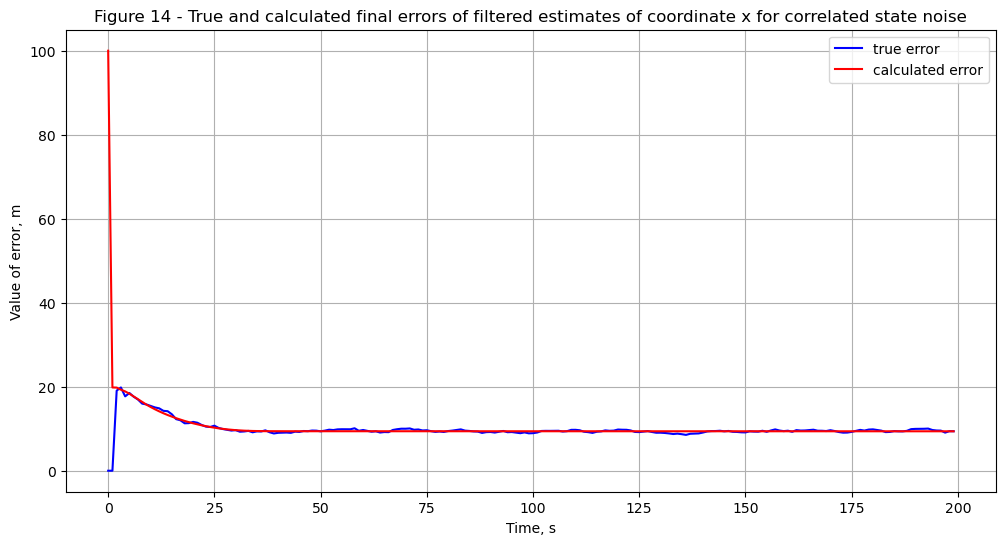

In [37]:
#Plot of the true and calculated errors of filtered estimates of coordinate x
plt.figure(figsize=(12, 6))
plt.plot(fin_err, color="blue",  label='true error')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='calculated error')
plt.title('Figure 14 - True and calculated final errors of filtered estimates of coordinate x for correlated state noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

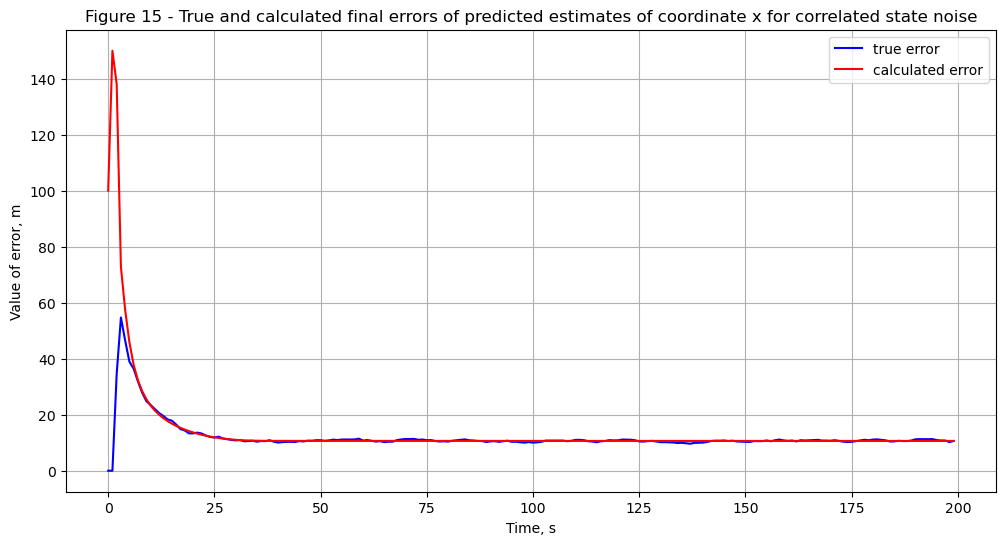

In [38]:
#Plot of the true and calculated errors of predicted estimates of coordinate x
plt.figure(figsize=(12, 6))
plt.plot(fin_err_pred, color="blue",  label='true error')
plt.plot(np.sqrt(P_viz[:,0,0]), color="red",  label='calculated error')
plt.title('Figure 15 - True and calculated final errors of predicted estimates of coordinate x for correlated state noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

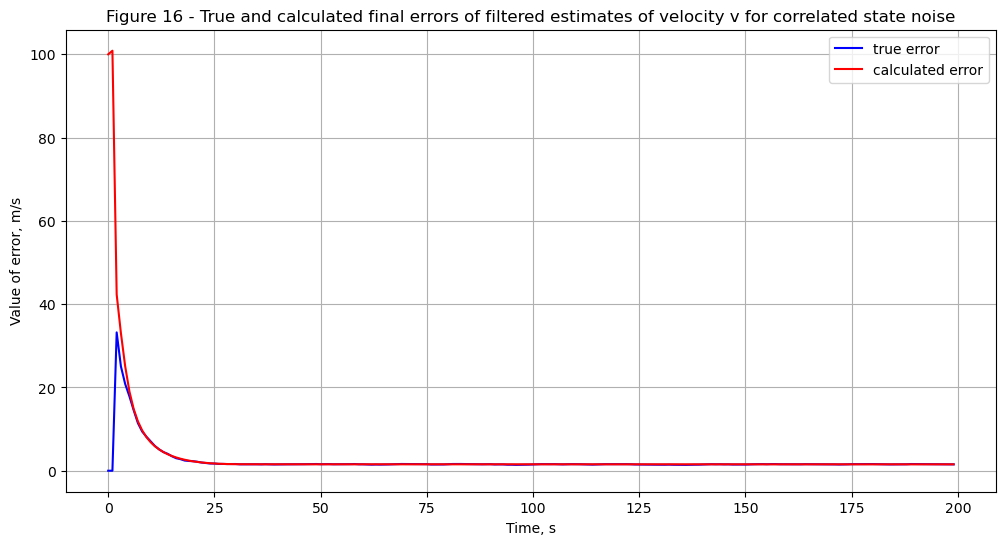

In [39]:
#Plot of the true and calculated errors of filtered estimates of velocity v
plt.figure(figsize=(12, 6))
plt.plot(fin_err_v, color="blue",  label='true error')
plt.plot(np.sqrt(P[:,1,1]), color="red",  label='calculated error')
plt.title('Figure 16 - True and calculated final errors of filtered estimates of velocity v for correlated state noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m/s')
plt.legend()
plt.grid()
plt.show()

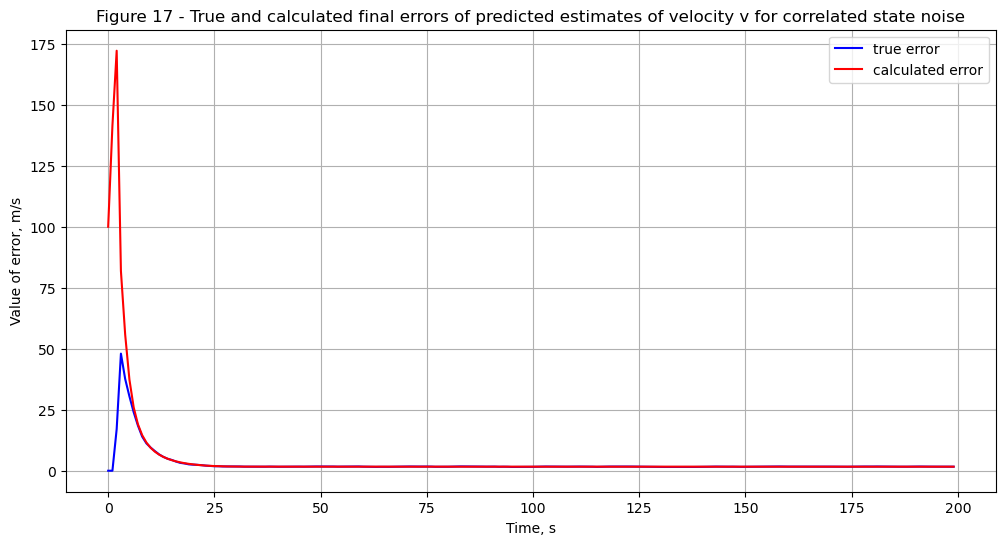

In [40]:
#Plot of the true and calculated errors of predicted estimates of velocity v
plt.figure(figsize=(12, 6))
plt.plot(fin_err_pred_v, color="blue",  label='true error')
plt.plot(np.sqrt(P_viz[:,1,1]), color="red",  label='calculated error')
plt.title('Figure 17 - True and calculated final errors of predicted estimates of velocity v for correlated state noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m/s')
plt.legend()
plt.grid()
plt.show()

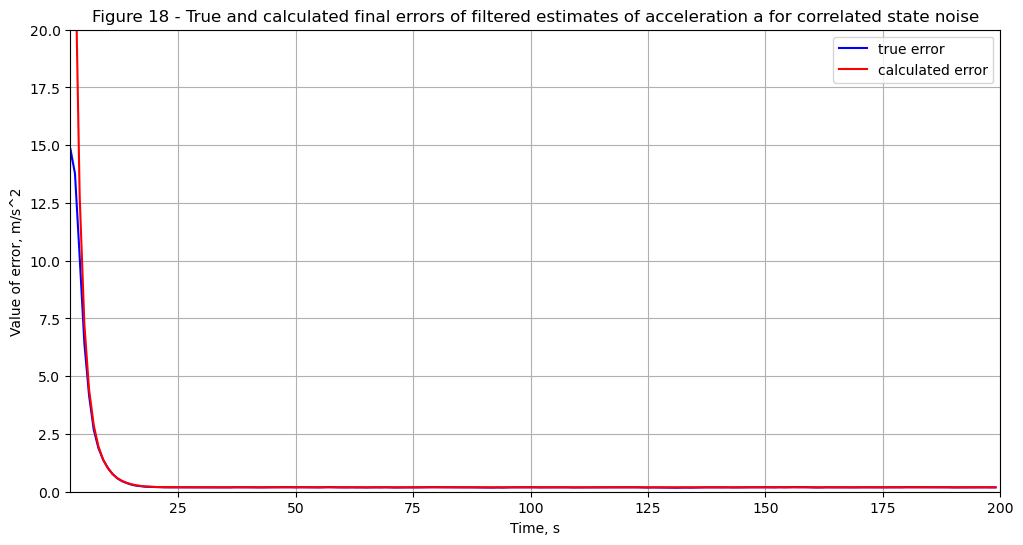

In [41]:
#Plot of the true and calculated errors of filtered estimates of acceleration a
plt.figure(figsize=(12, 6))
plt.plot(fin_err_a, color="blue",  label='true error')
plt.plot(np.sqrt(P[:,2,2]), color="red",  label='calculated error')
plt.title('Figure 18 - True and calculated final errors of filtered estimates of acceleration a for correlated state noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m/s^2')
plt.legend()
plt.grid()
plt.xlim(2,200)
plt.ylim(0, 20)
plt.show()

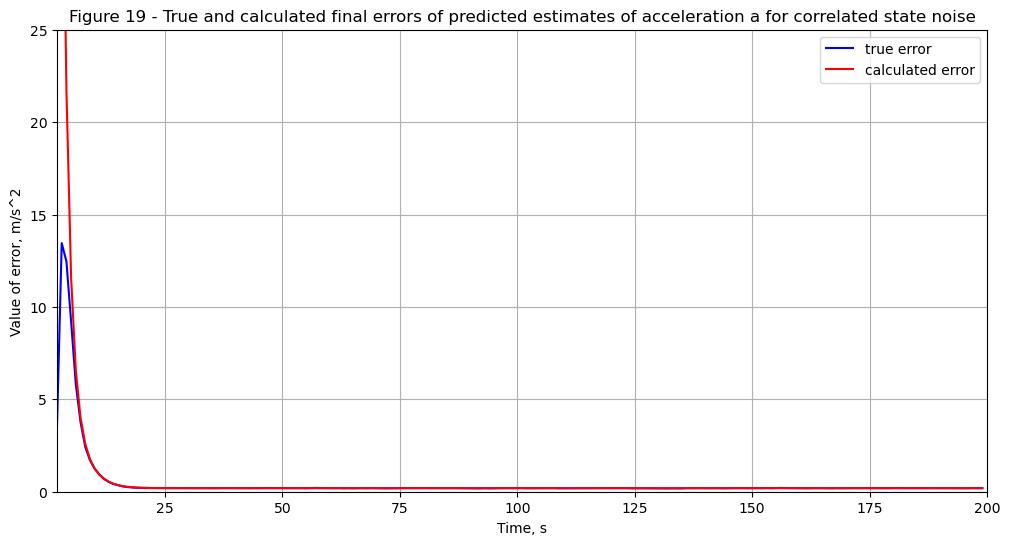

In [42]:
#Plot of the true and calculated errors of predicted estimates of acceleration a
plt.figure(figsize=(12, 6))
plt.plot(fin_err_pred_a, color="blue",  label='true error')
plt.plot(np.sqrt(P_viz[:,2,2]), color="red",  label='calculated error')
plt.title('Figure 19 - True and calculated final errors of predicted estimates of acceleration a for correlated state noise')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m/s^2')
plt.legend()
plt.grid()
plt.xlim(2,200)
plt.ylim(0, 25)
plt.show()

As we can see, in all 6 cases the true errors match the calculated errors. We can conclude that the Kalman filter is optimal in this case, takes into account correlated state noise and can be trusted.

**Conclusion:**

We conducted an analysis and found out that not taking into account the correlation of random variables in the Kalman filter can lead to an increase in the filtering error or even worsen the filtering accuracy, making the filtered estimates even less accurate than the raw data.

In order for the Kalman filter to be optimal, it is necessary to take into account the correlation of noise in the filter model. After we introduced a new state coordinate that takes into account the noise correlation, we came to the conclusion that the prediction and filtering errors coincided with the calculated ones, which indicates that our filter is optimal and can be trusted.

**Learning log:**

What we learned:

We found out that when we neglect the correlated state noise, we get a more accurate estimate than when we neglect the correlated measurement noise. We get the most inaccurate estimate when we do not take into account both the correlated state noise and the correlated measurement noise. 

We learned how to represent correlated noise as a Gauss-Markov first-order process

We learned how to account for correlated state noise in the Kalman filter model.

What difficulties we faced:

It was difficult to formulate a competent conclusion about the behavior of the filter by analyzing the true and calculated error graphs for different scenarios of the filter in the first part

It was difficult to create a Kalman filter state space model that takes into account correlated state noise